## SVM à marge souple from scratch 
#### (20/07/2025)

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

### Création de nos données
<p> On crée nos données de sorte à pouvoir les séparer linéairement avec notre SVM à marge rigide</p>

C:\Users\proma\AppData\Local\Temp\ipykernel_8972\891687374.py:14: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  nuage1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
C:\Users\proma\AppData\Local\Temp\ipykernel_8972\891687374.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  nuage2 = np.random.multivariate_normal(mean=mean2, cov=cov2, size=100)


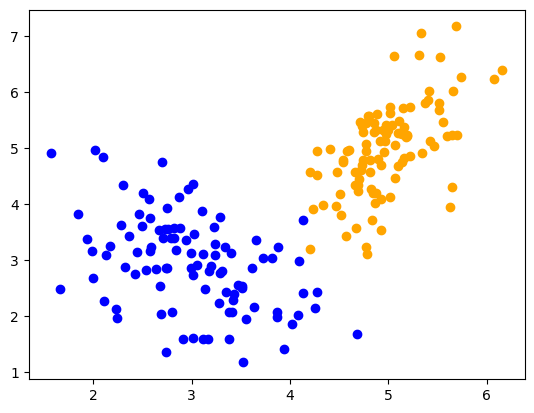

In [4]:
mean1 = [3, 3]
mean2 = [5, 5]

cov1 = [
    [0.5, -0.6],
    [0, 0.5]
]

cov2 = [
    [0.3, 0.6],
    [0, 0.3]
]

nuage1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
nuage1 = np.concatenate([ nuage1, np.full((len(nuage1), 1), -1) ], axis=1)

nuage2 = np.random.multivariate_normal(mean=mean2, cov=cov2, size=100)
nuage2 = np.concatenate([ nuage2, np.full((len(nuage2), 1), 1) ], axis=1)


plt.scatter(nuage1[:, 0], nuage1[:, 1], c='blue')
plt.scatter(nuage2[:, 0], nuage2[:, 1], c='orange')

#### On crée notre dataset

In [6]:
X = np.concatenate([nuage1, nuage2], axis=0)
bias = np.ones((X.shape[0], 1))                     
X = np.concatenate([bias, X], axis=1)              

X.shape

(200, 4)

In [7]:
X

array([[ 1.        ,  3.86847027,  1.98273778, -1.        ],
       [ 1.        ,  2.57926805,  3.17223052, -1.        ],
       [ 1.        ,  3.41582378,  2.0780189 , -1.        ],
       [ 1.        ,  2.01704544,  4.97574475, -1.        ],
       [ 1.        ,  2.67429408,  3.53396022, -1.        ],
       [ 1.        ,  3.37893466,  2.0659437 , -1.        ],
       [ 1.        ,  4.02383842,  1.85802905, -1.        ],
       [ 1.        ,  3.2298994 ,  3.58659423, -1.        ],
       [ 1.        ,  2.23142935,  2.12879567, -1.        ],
       [ 1.        ,  1.98805331,  3.16125158, -1.        ],
       [ 1.        ,  2.36909433,  3.43520892, -1.        ],
       [ 1.        ,  3.01166066,  1.60123119, -1.        ],
       [ 1.        ,  3.01926198,  4.36535748, -1.        ],
       [ 1.        ,  4.68285502,  1.68567582, -1.        ],
       [ 1.        ,  2.76166632,  3.56089176, -1.        ],
       [ 1.        ,  3.28209194,  2.23202089, -1.        ],
       [ 1.        ,  3.

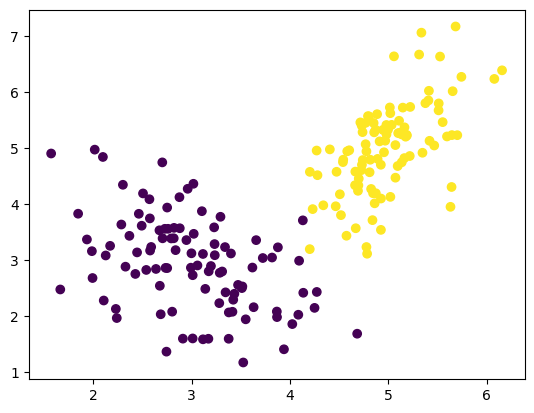

In [8]:
plt.scatter(X[:, 1], X[:, 2], c=X[:, 3])

### Dataset fleurs d'iris

In [233]:
from sklearn.datasets import load_iris

In [234]:
flowers = load_iris(as_frame=False).data
flowers = flowers[:, 2:4] # On ne garde que la longueur + largeur des pétales
target = load_iris(as_frame=False).target
target = target.reshape((len(target), 1))

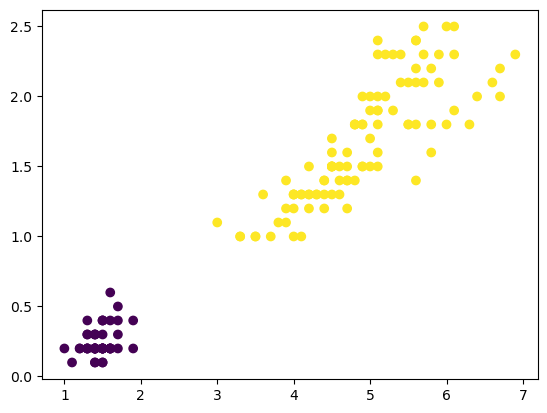

In [235]:
target = np.where(target == 0, -1, 1) # On fait du OneVersusAll : Sétosa == 0 et (Virginica, Versicolor) == 1

colonne_un = np.ones((len(flowers), 1))
df = np.hstack((flowers, target))
df = np.hstack((colonne_un, df))

plt.scatter(df[:, 1], df[:, 2], c=df[:, 3])

### Entrainement SVM

#### Fonction Coût (Hinge Loss)

$$ J(w) = \frac 1 2 ||w||^2 + \frac c m \sum \max(1-y_i (w_0+x_i .w),0) $$

In [236]:
def hinge_loss(w, X, Y, C):
    marge = 1 - (Y * (X @ w))
    hinge = np.maximum(0, marge)
    return (0.5 * np.dot(w.T, w)) + (C * np.mean(hinge))

#### Descente de gradient pour entraîner notre SVM à marge souple

$$ w = w - \alpha \frac{\partial }{\partial w}J(w) $$

$$
\frac{\partial }{\partial w}J(w) = \left\{
    \begin{array}{ll}
        w, & \mbox{si $ 1-y_i.(w_0+x_i.w) \le 0$} \\
        w - \sum \frac c m y_i . x_i, & \mbox{sinon.} 
    \end{array}
\right.
$$

In [237]:
def gradient_descent(X, Y, w, alpha, eps, C, max_iter):

    Y = Y.reshape((len(Y), 1))
    cout_new = 0
    cout_old = 1
    cout_historique = []
    w_new = w.copy()

    iteration = 0
    while(np.abs(cout_old - cout_new) > eps) and iteration < max_iter:
        cout_old = hinge_loss(w_new, X, Y, C)
        
        marges = 1 - (Y * (X @ w_new)) 
        
        #On initialise notre gradient
        gradient = np.zeros_like(w_new)
        gradient[1:] = w_new[1:] # On ne régularise pas le biais
        
        # On ajoute la contribution de chaque échantillon si la condition est respectée
        for i in range(len(X)):
            if marges[i] > 0:  # Si violation de la marge
                gradient = gradient - (C * Y[i] * X[i].reshape(-1, 1))/len(X)
        
        #  On met à jour nos poids
        w_new = w_new - alpha * gradient 
        
        cout_new = hinge_loss(w_new, X, Y, C)
        cout_historique.append(cout_new[0][0])
        iteration += 1
        
    return w_new, cout_new, cout_historique

In [238]:
np.random.seed(0)

w_alea = np.random.randn(len(df.T)-1, 1)
alpha = 0.001
eps = 1e-5
C = 30     #On choisit un C élevé afin de prioriser la minimisation des erreurs de classification.
#Si on aurait pris un C petit, on aurait priorisé des coefficients "w" plus petit et donc une marge plus large (quitte à avoir une frontière de décision qui ne sépare pas nos données)

max_iter = 1000

In [239]:
# On "lance" notre descente de gradient
w_optimal, final_cost, cout_histo = gradient_descent(df[:, :-1], df[:, -1], w_alea, alpha, eps, C, max_iter)

print("Poids optimisés :", w_optimal)
print("Coût final :", final_cost)

Poids optimisés : [[-1.67974765]
 [ 0.27875019]
 [ 1.28476854]]
Coût final : [[3.7672768]]


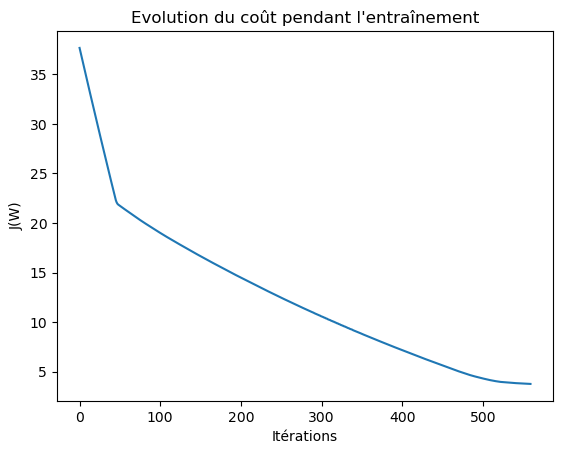

In [240]:
plt.plot(cout_histo)
plt.xlabel("Itérations")
plt.ylabel("J(W)")
plt.title("Evolution du coût pendant l\'entraînement")
plt.show()

#### On constate que la frontière de décision sépare nos 2 classes tout en maximisant la marge entre les points étants vecteurs de supports

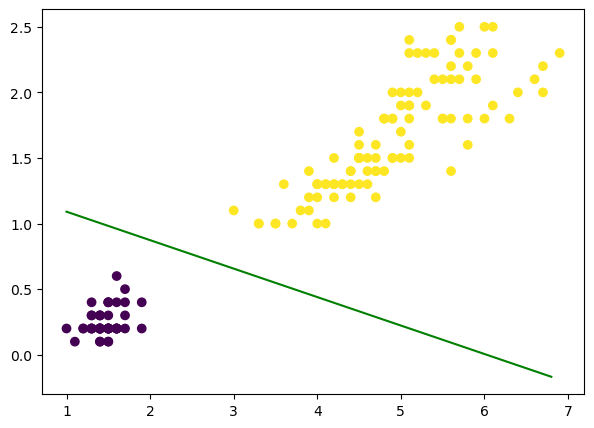

In [241]:
w0 = w_optimal[0]
w1, w2 = w_optimal[1], w_optimal[2]

xmin, xmax = df[:, 1].min(), df[:, 1].max()
Absx = np.arange(xmin, xmax, 0.1)

plt.figure(figsize=(7, 5))
plt.scatter(df[:, 1], df[:, 2], c=df[:, 3])
plt.plot(Absx, -(w0 + w1 * Absx) / w2, c='green')

## Entraînement d'un SVM avec SkLearn

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.datasets import load_iris

In [39]:
flowers = load_iris(as_frame=True).data
target = load_iris(as_frame=True).target
target = pd.DataFrame(target)

In [43]:
Pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

In [163]:
param_grid = [
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['poly'],
        'svc__degree' : [2, 3, 4, 5]
    },
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['linear']
    },
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['poly', 'rbf', 'sigmoid'],
        'svc__gamma' : ['scale', 'auto']
    }
]

In [165]:
grid = GridSearchCV(
    estimator = Pipe,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = StratifiedKFold(3), # On prend 3 petits folds car le dataset est assez petit
    n_jobs = 4 # On mobilise 4 coeurs du processeurs pour la parallélisation des tâches lors de l'entraînement
)

#### Train_Test_Split

In [168]:
X_train, X_test, Y_train, Y_test = train_test_split(flowers, target.to_numpy().ravel(), test_size=0.2, random_state=42, shuffle=True)

#### Entraînement du modèle de SVM

In [171]:
grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=4,
             param_grid=[{'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__degree': [2, 3, 4, 5],
                          'svc__kernel': ['poly']},
                         {'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__kernel': ['linear']},
                         {'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__gamma': ['scale', 'auto'],
                          'svc__kernel': ['poly', 'rbf', 'sigmoid']}],
             scoring='accuracy')

In [173]:
grid.best_params_

{'scaler': MinMaxScaler(),
 'svc__C': 20,
 'svc__gamma': 'auto',
 'svc__kernel': 'sigmoid'}

In [175]:
grid.best_score_

0.9666666666666667

In [139]:
model = grid.best_estimator_

In [141]:
model.predict(X_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])